# StarDist Training Test Notebook

This notebook demonstrates the StarDist training workflow using the **nuclei** test project:

1. **Setup** — point to the nuclei project (labels already exist)
2. **Generate patches from labels** — augment saved label crops into training patches
3. **Train** — train a StarDist2D model on the patches
4. **Predict** — run the trained model on a test image
5. **Visualise** — compare input, ground truth, and prediction

## 1. Import Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile

from napari_ai_lab.Augmenters.simple_augmenter import SimpleAugmenter
from napari_ai_lab.models.image_data_model import ImageDataModel
from napari_ai_lab.Segmenters.GlobalSegmenters.StardistSegmenter import (
    StardistSegmenter,
)

c:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\pixi\stardist8\.pixi\envs\default\lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info [ASN1: NOT_ENOUGH_DATA] not enough data (_ssl.c:4040)
  data = fetch_version_info()


## 2. Setup Project

The nuclei project already has saved label crops in `labels/input0` and `labels/truth0`.

In [2]:
# Use relative path from notebook location to test images
project_path = Path("../tests/test_images/nuclei").resolve()

image_data_model = ImageDataModel(str(project_path))

print(f"Project: {project_path}")
print(f"Images found: {image_data_model.get_image_count()}")
print(f"Labels dir: {image_data_model.get_labels_directory()}")
print(f"Label crops (input0): {list(image_data_model.get_labels_directory().glob('input0/*.tif'))}")

Project: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei
Images found: 200
Labels dir: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei\labels
Label crops (input0): [WindowsPath('C:/Users/bnort/work/ImageJ2022/tnia/napari-ai-lab/tests/test_images/nuclei/labels/input0/IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif'), WindowsPath('C:/Users/bnort/work/ImageJ2022/tnia/napari-ai-lab/tests/test_images/nuclei/labels/input0/IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00001.tif'), WindowsPath('C:/Users/bnort/work/ImageJ2022/tnia/napari-ai-lab/tests/test_images/nuclei/labels/input0/IXMtest_A12_s7_w1EAEEA614-51ED-43B3-A4FF-088730911E4C_00000.tif')]


## 3. Delete Old Patches and Generate New Patches from Labels

We use the `from_label_boxes` workflow: the augmenter reads label crops from disk and generates augmented training patches.

In [3]:
# Delete old patches
image_data_model.delete_patches(axis="yx")

# Create augmenter and configure patch generation
augmenter = SimpleAugmenter()
image_data_model.set_augmenter(augmenter)
image_data_model.set_patch_size((256, 256))
image_data_model.set_num_patches(200)

# Generate patches from the saved label crops
patches_dir = image_data_model.generate_patches_from_labels() #axis="yx", axes_string="YX")

print(f"\nPatches directory: {patches_dir}")
print(f"Input patches: {len(list(Path(patches_dir, 'input0').glob('*.tif')))}")
print(f"Truth patches: {len(list(Path(patches_dir, 'ground_truth0').glob('*.tif')))}")

🎨 Generating 200 patches × 3 label crop(s) = 600 total...
Computed global normalization stats: low=0.0055, high=0.1781
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (10/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (20/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (30/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (40/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (50/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (60/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (70/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (80/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (90/600)

## 4. Visualise a Few Patches

Quick sanity check — display some input/truth patch pairs.

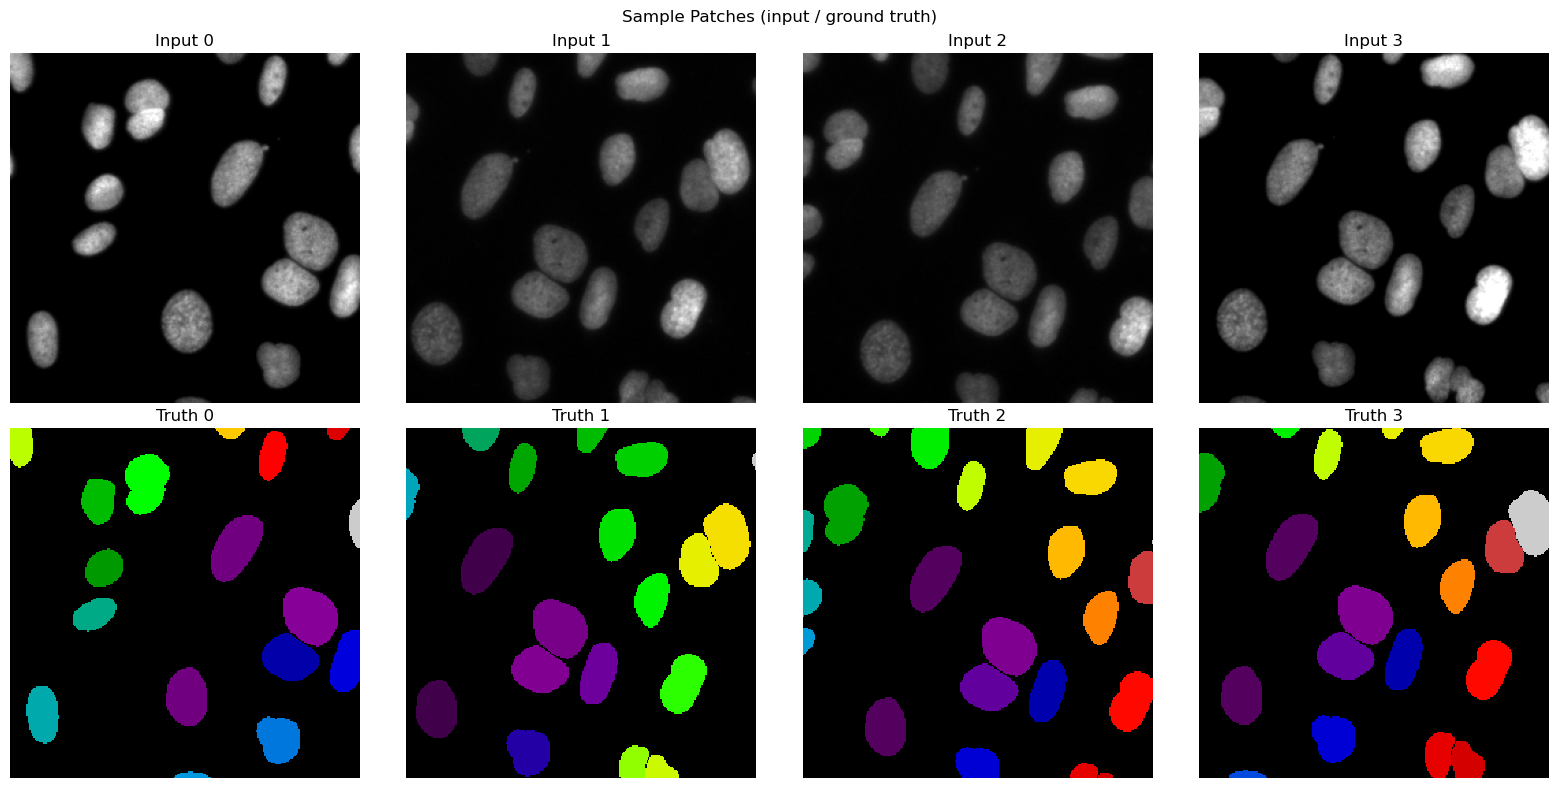

In [6]:
input_patches = sorted(Path(patches_dir, "input0").glob("*.tif"))
truth_patches = sorted(Path(patches_dir, "ground_truth0").glob("*.tif"))

n_show = min(4, len(input_patches))
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))

for i in range(n_show):
    inp = tifffile.imread(str(input_patches[i]))
    gt = tifffile.imread(str(truth_patches[i]))

    axes[0, i].imshow(inp, cmap="gray")
    axes[0, i].set_title(f"Input {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(gt, cmap="nipy_spectral", interpolation="nearest")
    axes[1, i].set_title(f"Truth {i}")
    axes[1, i].axis("off")

plt.suptitle("Sample Patches (input / ground truth)")
plt.tight_layout()
plt.show()

## 5. Train StarDist2D Model

Create a `StardistSegmenter`, set training hyper-parameters, and call `train()`.

In [18]:
segmenter = StardistSegmenter()

# Training hyper-parameters (kept small for a quick test)
segmenter.num_epochs = 50
segmenter.steps_per_epoch = 50
segmenter.train_patch_size_y = 256
segmenter.train_patch_size_x = 256

# Set paths on segmenter (same as _run_training does in the GUI)
segmenter.patch_path = str(patches_dir)
segmenter.model_name = "stardist_nuclei_test"
segmenter.training_model_name = segmenter.model_name
segmenter.model_save_dir = str(project_path / "models")

model_name = segmenter.model_name
model_base_path = segmenter.model_save_dir

print(f"Patch path:  {segmenter.patch_path}")
print(f"Model name:  {model_name}")
print(f"Model base:  {model_base_path}")

Patch path:  C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei\patches\patches_axis_yx
Model name:  stardist_nuclei_test
Model base:  C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei\models


In [14]:
# Run training (same signature as MonaiUNetSegmenter.train)
result = segmenter.train()
print(result)

# Extract history object for plotting
training_history = result.get("history")
print(f"\nTraining history captured: {training_history is not None}")

0it [00:00, ?it/s]dl_util.py (117): The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
dl_util.py (118): The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
dl_util.py (117): The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
dl_util.py (118): The plugin infrastructure in `skimage.io` and the parameter `plu

🏋️ Training StarDist2D: 598 train, 2 val
   axes=YX, n_channel_in=1
   epochs=20, steps_per_epoch=50
   train_patch_size=(128, 128)
Using default values: prob_thresh=0.5, nms_thresh=0.4.
   Saved downsize_factor=1 to custom_params.json
Epoch 1/20
50/50 [==============================] - 7s 117ms/step - loss: 2.1836 - prob_loss: 0.4161 - dist_loss: 8.8379 - prob_kld: 0.3354 - dist_relevant_mae: 8.8373 - dist_relevant_mse: 131.1394 - dist_dist_iou_metric: 0.1950 - val_loss: 1.6056 - val_prob_loss: 0.2751 - val_dist_loss: 6.6523 - val_prob_kld: 0.1910 - val_dist_relevant_mae: 6.6509 - val_dist_relevant_mse: 70.9552 - val_dist_dist_iou_metric: 0.3971 - lr: 3.0000e-04
Epoch 2/20
50/50 [==============================] - 4s 90ms/step - loss: 1.4844 - prob_loss: 0.2379 - dist_loss: 6.2328 - prob_kld: 0.1567 - dist_relevant_mae: 6.2317 - dist_relevant_mse: 68.3566 - dist_dist_iou_metric: 0.3435 - val_loss: 1.4938 - val_prob_loss: 0.2328 - val_dist_loss: 6.3049 - val_prob_kld: 0.1487 - val_dist_

## 6. Plot Training Loss

Convert the Keras History object to a DataFrame and visualize the training curves.

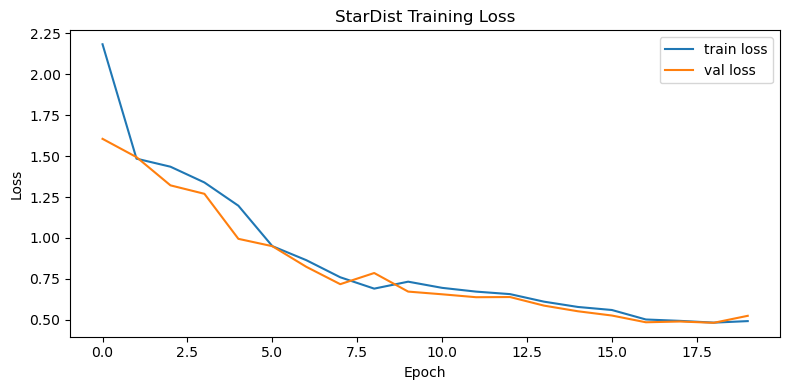


Training summary:
 epoch     loss  val_loss
     0 2.183630  1.605559
     1 1.484416  1.493793
     2 1.435204  1.321226
     3 1.338891  1.269579
     4 1.196814  0.994385
     5 0.949774  0.949422
     6 0.863987  0.823422
     7 0.759450  0.717227
     8 0.689998  0.785449
     9 0.732515  0.671883
    10 0.694748  0.655411
    11 0.671747  0.637552
    12 0.656495  0.638636
    13 0.610373  0.586155
    14 0.577921  0.551608
    15 0.559386  0.525610
    16 0.501412  0.484361
    17 0.493064  0.489061
    18 0.482186  0.481189
    19 0.491514  0.523890


In [15]:
import pandas as pd

# Convert history object to DataFrame (compatible with CSV format)
if training_history is not None:
    # history.history is a dict like {'loss': [...], 'val_loss': [...]}
    history_dict = training_history.history

    # Create DataFrame with epoch numbers
    df = pd.DataFrame({
        'epoch': range(len(history_dict.get('loss', []))),
        'loss': history_dict.get('loss', []),
        'val_loss': history_dict.get('val_loss', [])
    })

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(df["epoch"], df["loss"], label="train loss")
    if "val_loss" in df.columns and df["val_loss"].notna().any():
        ax.plot(df["epoch"], df["val_loss"], label="val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("StarDist Training Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("\nTraining summary:")
    print(df.to_string(index=False))
else:
    print("No training history available. Run the training cell first.")

## 7. Predict on a Test Image

Load one of the nuclei images and run the trained model via `segmenter.segment()`.

In [16]:
# Load a test image from the project
test_images = sorted(project_path.glob("*.tif"))
test_image = tifffile.imread(str(test_images[0]))
print(f"Test image: {test_images[0].name}, shape={test_image.shape}, dtype={test_image.dtype}")

# The trained model is already on segmenter.custom_model after train()
predicted_labels = segmenter.segment(test_image)
print(f"Predicted labels: shape={predicted_labels.shape}, unique={len(np.unique(predicted_labels)) - 1} objects")

Test image: IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB.tif, shape=(520, 696), dtype=uint16
Using model: stardist_nuclei_test (axis: YX)
   Downsized image: (520, 696) → (260, 348) (factor=2)
🔍 StarDist input: shape=(260, 348), dtype=float32, ndim=2
🔍 TensorFlow GPU Check:
   TensorFlow version: 2.10.1
   GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Built with CUDA: True
   ✅ GPU ENABLED - using GPU acceleration
🔍 Calling model.predict_instances with shape=(260, 348), axes=None (will use model default)
   Upsized labels back to original: (260, 348) → (520, 696)
StarDist: Found 88 objects (prob_thresh=0.5, nms_thresh=0.4)
Predicted labels: shape=(520, 696), unique=88 objects


## 8. Visualise Prediction

Side-by-side comparison of input, ground truth annotation (if available), and the StarDist prediction.

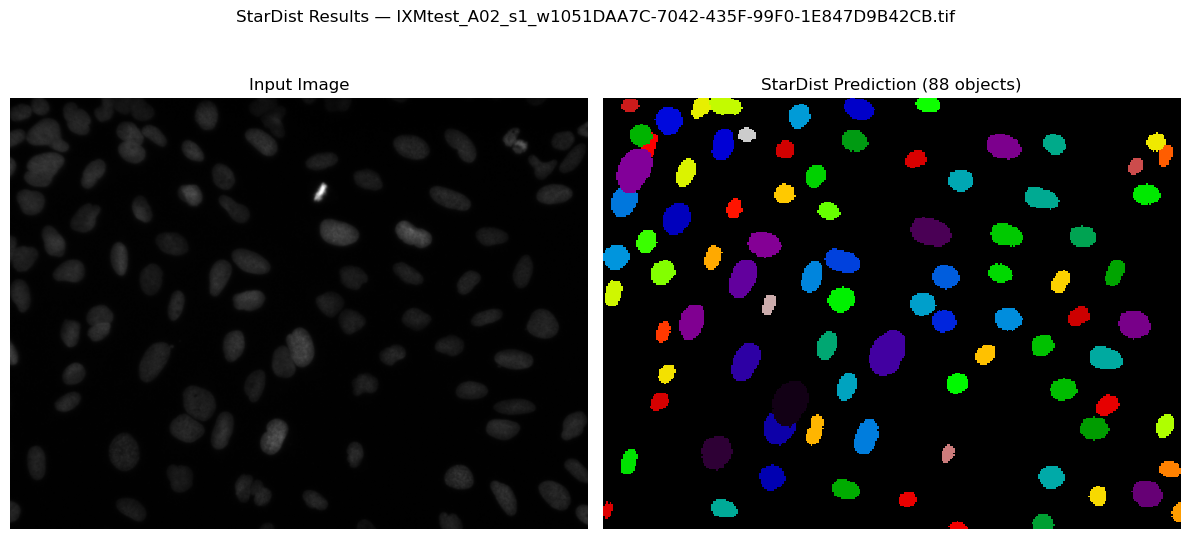

In [17]:
# Try to load an existing annotation for the same image
annotations_dir = project_path / "annotations"
annotation_name = test_images[0].stem + ".tif"
annotation_path = annotations_dir / annotation_name

has_gt = annotation_path.exists()

ncols = 3 if has_gt else 2
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))

axes[0].imshow(test_image, cmap="gray")
axes[0].set_title("Input Image")
axes[0].axis("off")

if has_gt:
    gt = tifffile.imread(str(annotation_path))
    axes[1].imshow(gt, cmap="nipy_spectral", interpolation="nearest")
    axes[1].set_title(f"Ground Truth ({len(np.unique(gt)) - 1} objects)")
    axes[1].axis("off")
    pred_ax = axes[2]
else:
    pred_ax = axes[1]

pred_ax.imshow(predicted_labels, cmap="nipy_spectral", interpolation="nearest")
pred_ax.set_title(f"StarDist Prediction ({len(np.unique(predicted_labels)) - 1} objects)")
pred_ax.axis("off")

plt.suptitle(f"StarDist Results — {test_images[0].name}")
plt.tight_layout()
plt.show()

## 9. Overlay — Input with Prediction Contours

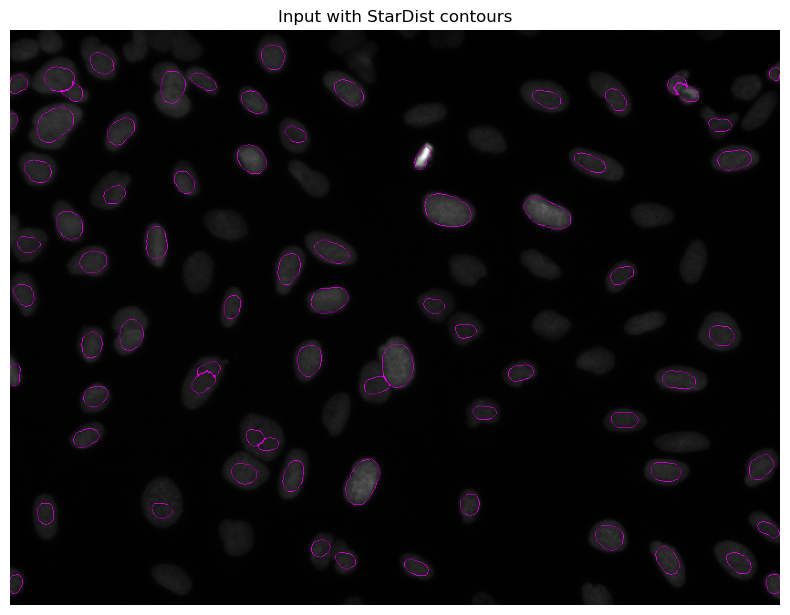

In [10]:
from skimage.segmentation import find_boundaries

boundaries = find_boundaries(predicted_labels, mode="outer")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(test_image, cmap="gray")
ax.imshow(np.ma.masked_where(~boundaries, boundaries), cmap="spring", alpha=0.8)
ax.set_title("Input with StarDist contours")
ax.axis("off")
plt.tight_layout()
plt.show()

## Summary

| Step | What happened |
|------|---------------|
| **Setup** | Pointed to `tests/test_images/nuclei/` — labels already on disk |
| **Patches** | `generate_patches_from_labels` augmented 3 label crops × 200 = 600 patches |
| **Train** | `StardistSegmenter.train()` → Config2D + StarDist2D, 20 epochs |
| **Predict** | `segmenter.segment(image)` using the just-trained custom model |
| **Visualise** | Side-by-side comparison + boundary overlay |